# Visualize inversion results

Use this notebook to visualize some standard inversion results.

See `utils.py` for the code to generate plots and count observations in the region of interest (imported below).

Notebook can be accessed via AWS following these instructions: https://docs.aws.amazon.com/dlami/latest/devguide/setup-jupyter.html)

In [6]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib
import sys
import os
import glob
import re
import datetime
import pickle as pickle
import pandas as pd
import xesmf as xe
import cartopy
import cartopy.crs as ccrs
import colorcet as cc
from shapely.geometry.polygon import Polygon
import shapely.ops as ops
from functools import partial
import pyproj

from utils import (
    plot_field,
    plot_field_gchp,
    load_obj,
    sum_total_emissions,
    count_obs_in_mask,
    get_posterior_emissions,
    get_mean_emissions,
    plot_ensemble,
    plot_hyperparameter_analysis,
    export_visualization_outputs,
)

from config_utils import load_config

import warnings

warnings.filterwarnings("ignore", category=FutureWarning)

## Setup

In [7]:
# Read the configuration file
# config = load_config("/n/holylfs05/LABS/jacob_lab/Users/msulprizio/Test_Permian_1week/config_Test_Permian_1week.yml")
config = load_config("/orcd/data/dvaron/001/IMI/outputs/vedrau/baseline_jacobian_inversion3/config_baseline_jacobian_inversion3.yml")

# Save out the species as its own variable
species = config["Species"]

In [8]:
if config['UseGCHP']:
    CSgridDir = f"{os.path.expandvars(config['OutputPath']) }/{config['RunName']}/CS_grids"
    gridfpath = f"{CSgridDir}/grids.c{config['CS_RES']}.nc"
    grid_ds = xr.open_dataset(gridfpath)

# Paths to prior emissions, inversion results, GEOS/satellite data, posterior simulation
# update prior prefix and period based on whether using kalman mode
if config["KalmanMode"]:
    prior_prefix = "./../.."
    period = int(os.getcwd().split("kf_inversions/period")[-1])  # get current period
    periods_df = pd.read_csv("./../../periods.csv")
    start_date = periods_df.iloc[period - 1, 0]
    end_date = periods_df.iloc[period - 1, 1]
    prior_sf_pth = f"{prior_prefix}/archive_sf/prior_sf_period{period}.nc"
else:
    prior_prefix = "./.."
    start_date = config["StartDate"]
    end_date = config["EndDate"]

prior_cache = f"{prior_prefix}/hemco_prior_emis/OutputDir/"
gc_fpath = f"./data_geoschem/GEOSChem.SpeciesConc.{start_date}_0000z.nc4"

satdat_dir = (
    "./data_converted_prior" if config["LognormalErrors"] else "./data_converted"
)
results_pth = (
    "./gridded_posterior_ln.nc"
    if config["LognormalErrors"]
    else "./gridded_posterior.nc"
)
inversion_result_path = (
    "./inversion_result_ln.nc" if config["LognormalErrors"] else "./inversion_result.nc"
)
posterior_dir = "./data_converted_posterior"
visualization_dir = (
    "./data_visualization_prior"
    if config["LognormalErrors"]
    else "./data_visualization"
)
posterior_viz_dir = "./data_visualization_posterior"

plot_save_path = ("./output" if not config["KalmanMode"] else f"../output/period_{period}_plots")

In [9]:
# Open the state vector file
if config["KalmanMode"] and config["DynamicKFClustering"]:
    state_vector_filepath = f"./../../archive_sv/StateVector_{period}.nc"
else:
    state_vector_filepath = "./../StateVector.nc"

state_vector = xr.open_dataset(state_vector_filepath).squeeze()
state_vector_labels = state_vector["StateVector"]

# Identify the last element of the region of interest
last_ROI_element = int(
    np.nanmax(state_vector_labels.values) - config["nBufferClusters"]
)

# Define mask for region of interest
mask = (state_vector_labels <= last_ROI_element)

In [10]:
# Set latitude/longitude bounds for plots
if not config['UseGCHP']:
    # Trim 0.5-2.5 degrees to remove GEOS-Chem buffer zone
    if config["Res"] == "0.125x0.15625":
        degx = 4 * 0.15625
        degy = 4 * 0.125
    elif config["Res"] == "0.25x0.3125":
        degx = 4 * 0.3125
        degy = 4 * 0.25
    elif config["Res"] == "0.5x0.625":
        degx = 4 * 0.625
        degy = 4 * 0.5
    elif config["Res"] == "2.0x2.5":
        degx = 4 * 2.5
        degy = 4 * 2.0

    lon_bounds = [
        np.min(state_vector.lon.values) + degx,
        np.max(state_vector.lon.values) - degx,
    ]
    lat_bounds = [
        np.min(state_vector.lat.values) + degy,
        np.max(state_vector.lat.values) - degy,
    ]
elif config['STRETCH_GRID']:
    buffer_bounds = 0.
    temp_lons = grid_ds['corner_lons'].values[5,...].copy()
    temp_lons[temp_lons>180] -= 360
    lon_min = max(temp_lons.min() - buffer_bounds, -180)
    lon_max = min(temp_lons.max() + buffer_bounds, 180)
    lat_min = max(grid_ds['corner_lats'].values[5,...].min(), -90)
    lat_max = min(grid_ds['corner_lats'].values[5,...].max(), 90)
    lon_bounds = [lon_min, lon_max]
    lat_bounds = [lat_min, lat_max]
else:
    lon_bounds = [-180, 180]
    lat_bounds = [-90, 90]

## State vector

Plot saved to ./output/state_vector_elements.png


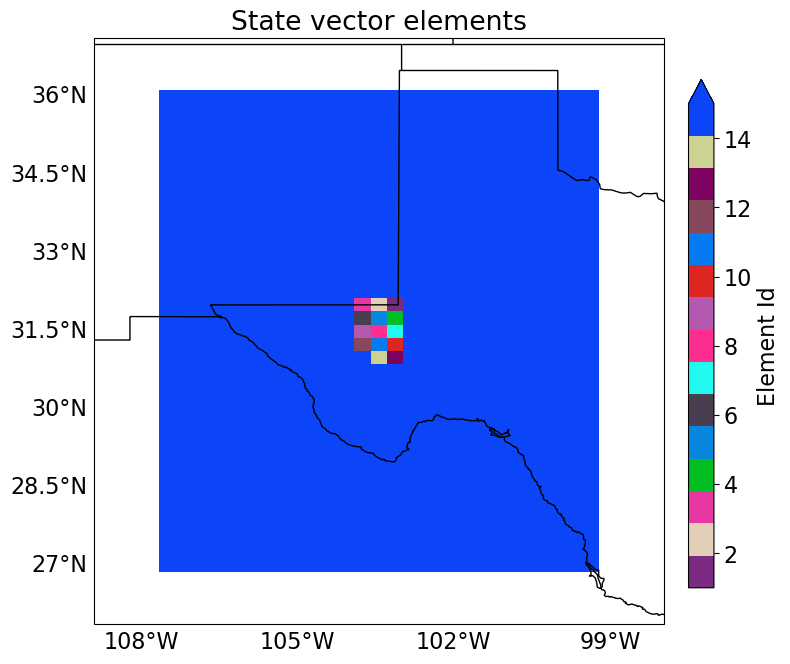

In [11]:
fig = plt.figure(figsize=(8, 8))
plt.rcParams.update({"font.size": 16})
ax = fig.subplots(1, 1, subplot_kw={"projection": ccrs.PlateCarree()})
num_colors = state_vector_labels.where(mask).max().item()
sv_cmap = matplotlib.colors.ListedColormap(np.random.rand(int(num_colors), 3))

if not config['UseGCHP']:
    plot_field(
        ax,
        state_vector_labels,
        cmap=sv_cmap,
        vmin=1,
        vmax=num_colors,
        title="State vector elements",
        cbar_label="Element Id",
        is_regional=config["isRegional"],
        save_path=plot_save_path
    )
else:
    plot_field_gchp(
        ax,
        grid_ds['corner_lons'],
        grid_ds['corner_lats'],
        state_vector_labels,
        lon_bounds=lon_bounds,
        lat_bounds=lat_bounds,
        cmap=sv_cmap,
        vmin=1,
        vmax=num_colors,
        title="State vector elements",
        cbar_label="Element Id",
        is_regional=config["isRegional"],
        stretch_grid=config['STRETCH_GRID'],
        save_path=plot_save_path
    )

## Prior and posterior emissions in the region of interest

In [12]:
# Prior emissions
prior_ds = get_mean_emissions(start_date, end_date, prior_cache)
if config["OptimizeSoil"]:
    prior = prior_ds[f"Emis{species}_Total"]
else:
    prior = prior_ds[f"Emis{species}_Total_ExclSoilAbs"]

if config["KalmanMode"]:
    # properly apply nudged sfs to prior in Kalman mode
    prior_sf = xr.open_dataset(prior_sf_pth)
    prior_ds = get_posterior_emissions(prior_ds, prior_sf, species, config["OptimizeSoil"])
    prior = prior_ds[f"Emis{species}_Total"]

# Optimized scale factors
scale_ds = xr.open_dataset(results_pth)
scale = scale_ds["ScaleFactor"]

# ensemble results
ens_scale_ds = xr.open_dataset(results_pth.replace(".nc", "_ensemble.nc"))
ens_inv_result = xr.open_dataset(inversion_result_path.replace(".nc", "_ensemble.nc"))

# Posterior emissions
posterior_ds = get_posterior_emissions(prior_ds, scale_ds, species, config["OptimizeSoil"])
if config["OptimizeSoil"]:
    posterior = posterior_ds[f"Emis{species}_Total"]
else:
    posterior = posterior_ds[f"Emis{species}_Total_ExclSoilAbs"]

In [13]:
# Total emissions in the region of interest
if config['UseGCHP']:
    areas = grid_ds['area']
else: 
    areas = prior_ds["AREA"]

total_prior_emissions = sum_total_emissions(prior, areas, mask)
total_posterior_emissions = sum_total_emissions(posterior, areas, mask)

print("Prior         emissions :", total_prior_emissions, "Tg/y")
print(
    "Posterior     emissions :",
    total_posterior_emissions,
    "Tg/y (mean xhat)",
)

# Plot the ensemble of posterior emissions
# and calculate the mean and standard deviation
# Note: update the exclude_members list to exclude ensemble members from the analysis
# integer list of ensemble members to exclude from analysis
exclude_members = []  # eg. [0, 4, 5]
ensemble_members = ens_scale_ds.ensemble.values
ensemble_members = [num for num in ensemble_members if num not in exclude_members]
num_ensemble_members = len(ensemble_members)

if num_ensemble_members > 1:
    ensemble_posteriors = []
    for imem in ensemble_members:
        ensemble_posteriors.append(
            get_posterior_emissions(
                prior_ds, ens_scale_ds.sel(ensemble=imem)["ScaleFactor"], config["OptimizeSoil"]
            )
        )

    ens_totals_posterior = np.array(
        [
            sum_total_emissions(item["EmisCH4_Total_ExclSoilAbs"], areas, mask)
            for item in ensemble_posteriors
        ]
    )
    ens_totals_min = np.min(ens_totals_posterior)
    ens_totals_max = np.max(ens_totals_posterior)
    print("Ensemble range:", f" {ens_totals_min}-{ens_totals_max} Tg/yr")

    # Plot the totals
    fig = plt.figure(figsize=(8, 8))
    plt.rcParams.update({"font.size": 14})
    ax = fig.subplots(1, 1)
    plot_ensemble(
        ax,
        ens_totals_posterior,
        total_prior_emissions,
        plot_save_path=plot_save_path,
    )

Prior         emissions : 0.12428819244519287 Tg/y
Posterior     emissions : 0.15360071378894807 Tg/y (mean xhat)


In [14]:
# Plot sensitivity of total emissions to hyperparameters
if num_ensemble_members > 1:
    # Collect parameters with multiple values used in ensemble members
    params = [
        "prior_err",
        "obs_err",
        "gamma",
        "prior_err_bc",
        "prior_err_oh",
    ]
    if config["LognormalErrors"]:
        params.append("prior_err_buffer")
    params_dict = {
        key: ens_inv_result[key].values[ensemble_members]
        for key in params
        if len(np.unique(ens_inv_result[key].values[ensemble_members])) > 1
    }

    # Only proceed if there are axes to plot
    num_axes = len(params_dict.keys())
    if num_axes > 0:
        fig, axs = plt.subplots(num_axes, 1, figsize=(8, 3 * num_axes), squeeze=False)
        plt.rcParams.update({"font.size": 14})
        plot_hyperparameter_analysis(axs, ens_totals_posterior, params_dict)

Plot saved to ./output/prior_emissions.png


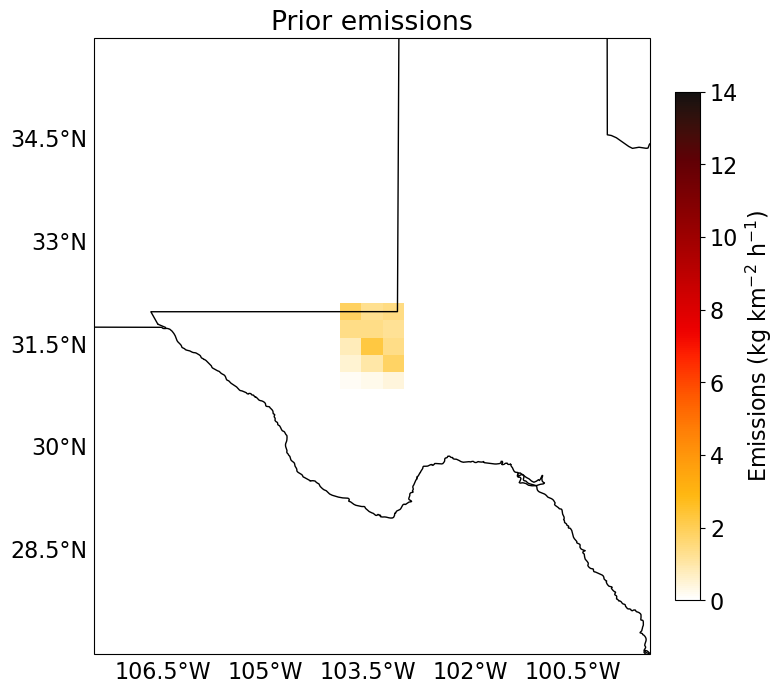

In [15]:
# Plot prior emissions
fig = plt.figure(figsize=(8, 8))
plt.rcParams.update({"font.size": 16})
ax = fig.subplots(1, 1, subplot_kw={"projection": ccrs.PlateCarree()})

prior_kgkm2h = prior * (1000**2) * 60 * 60  # Units kg/km2/h

if config['UseGCHP']:
    plot_field_gchp(
        ax,
        grid_ds['corner_lons'],
        grid_ds['corner_lats'],
        prior_kgkm2h,
        cmap=cc.cm.linear_kryw_5_100_c67_r,
        lon_bounds=lon_bounds,
        lat_bounds=lat_bounds,
        vmin=0,
        vmax=14,
        title="Prior emissions",
        cbar_label="Emissions (kg km$^{-2}$ h$^{-1}$)",
        only_ROI=True,
        state_vector_labels=state_vector_labels,
        last_ROI_element=last_ROI_element,
        is_regional=config["isRegional"],
        stretch_grid=config['STRETCH_GRID'],
        save_path=plot_save_path
    )
else:
    plot_field(
        ax,
        prior_kgkm2h,
        cmap=cc.cm.linear_kryw_5_100_c67_r,
        lon_bounds=lon_bounds,
        lat_bounds=lat_bounds,
        vmin=0,
        vmax=14,
        title="Prior emissions",
        cbar_label="Emissions (kg km$^{-2}$ h$^{-1}$)",
        only_ROI=True,
        state_vector_labels=state_vector_labels,
        last_ROI_element=last_ROI_element,
        is_regional=config["isRegional"],
        save_path=plot_save_path
    )

Plot saved to ./output/posterior_emissions.png


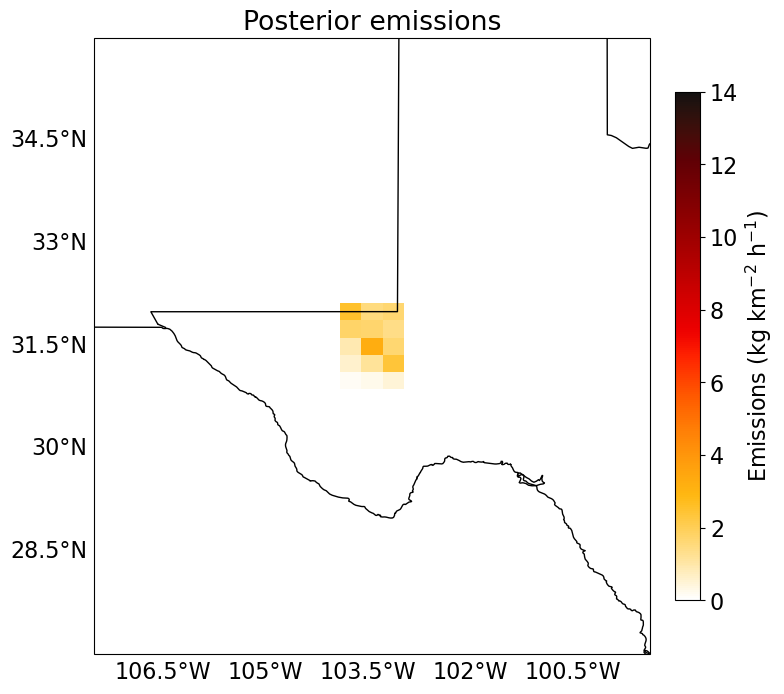

In [16]:
# Plot posterior emissions
fig = plt.figure(figsize=(8, 8))
plt.rcParams.update({"font.size": 16})
ax = fig.subplots(1, 1, subplot_kw={"projection": ccrs.PlateCarree()})

posterior_kgkm2h = posterior * (1000**2) * 60 * 60  # Units kg/km2/h

if config['UseGCHP']:
    plot_field_gchp(
        ax,
        grid_ds['corner_lons'],
        grid_ds['corner_lats'],
        posterior_kgkm2h,
        cmap=cc.cm.linear_kryw_5_100_c67_r,
        lon_bounds=lon_bounds,
        lat_bounds=lat_bounds,
        vmin=0,
        vmax=14,
        title="Posterior emissions",
        cbar_label="Emissions (kg km$^{-2}$ h$^{-1}$)",
        only_ROI=True,
        state_vector_labels=state_vector_labels,
        last_ROI_element=last_ROI_element,
        is_regional=config["isRegional"],
        stretch_grid=config['STRETCH_GRID'],
        save_path=plot_save_path
    )
else:
    plot_field(
        ax,
        posterior_kgkm2h,
        cmap=cc.cm.linear_kryw_5_100_c67_r,
        lon_bounds=lon_bounds,
        lat_bounds=lat_bounds,
        vmin=0,
        vmax=14,
        title="Posterior emissions",
        cbar_label="Emissions (kg km$^{-2}$ h$^{-1}$)",
        only_ROI=True,
        state_vector_labels=state_vector_labels,
        last_ROI_element=last_ROI_element,
        is_regional=config["isRegional"],
        save_path=plot_save_path
    )

## Sectoral Emissions

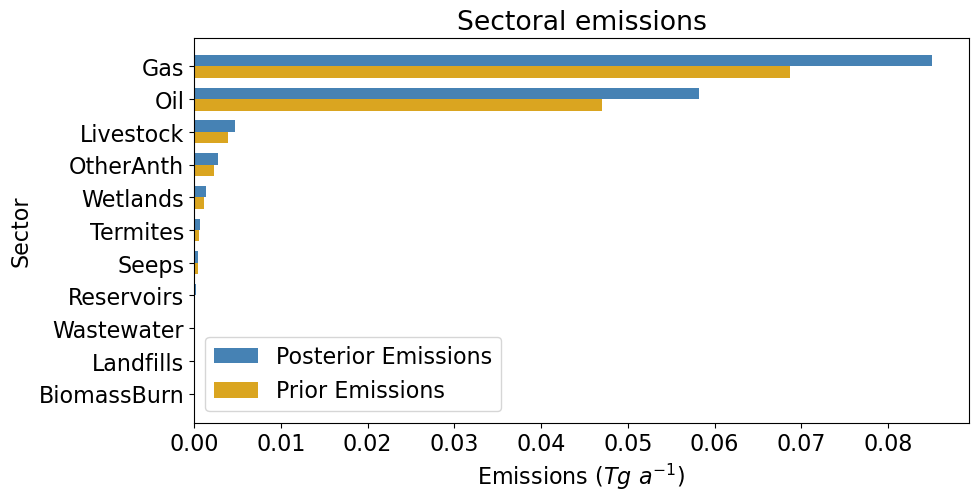

In [17]:
# Extract sector names
if not config['OptimizeSoil']:
    sectors = [
        var
        for var in list(posterior_ds.keys())
        if "EmisCH4" in var and not ("Total" in var or "Excl" in var or "Soil" in var)
    ]
else:
    sectors = [
        var
        for var in list(posterior_ds.keys())
        if "EmisCH4" in var and not ("Total" in var or "Excl" in var)
    ]

# Calculate total emissions for each sector
prior_sector_vals = []
post_sector_vals = []
sector_names = []
for sector in sectors:
    post_val = sum_total_emissions(posterior_ds[sector], areas, mask)
    prior_val = sum_total_emissions(prior_ds[sector], areas, mask)
    if (abs(post_val)>0) or (abs(prior_val)>0):
        post_sector_vals.append(post_val)
        prior_sector_vals.append(prior_val)
        sector_names.append(sector.replace(f"Emis{species}_", ""))


# Combine the lists into tuples and sort them based on post_sector_vals
combined = list(zip(sector_names, prior_sector_vals, post_sector_vals))
combined_sorted = sorted(combined, key=lambda x: x[2])
sector_names, prior_sector_vals, post_sector_vals = zip(*combined_sorted)

# Plot bars for prior and posterior
fig = plt.figure(figsize=(10, 5))
ax = fig.subplots(1, 1)
bar_height = 0.35
ind = np.arange(len(sector_names))
bars2 = ax.barh(
    ind + bar_height / 2,
    post_sector_vals,
    bar_height,
    color="steelblue",
    label="Posterior Emissions",
)
bars1 = ax.barh(
    ind - bar_height / 2,
    prior_sector_vals,
    bar_height,
    color="goldenrod",
    label="Prior Emissions",
)

# Add labels, title, and legend
ax.set_xlabel("Emissions ($Tg\ a^{-1}$)")
ax.set_ylabel("Sector")
ax.set_title("Sectoral emissions")
ax.set_yticks(ind)
ax.set_yticklabels(sector_names)
ax.legend()

plt.savefig(f"{plot_save_path}/Sectoral_emissions.png", bbox_inches="tight")

## Scale factors

Plot saved to ./output/scale_factors.png


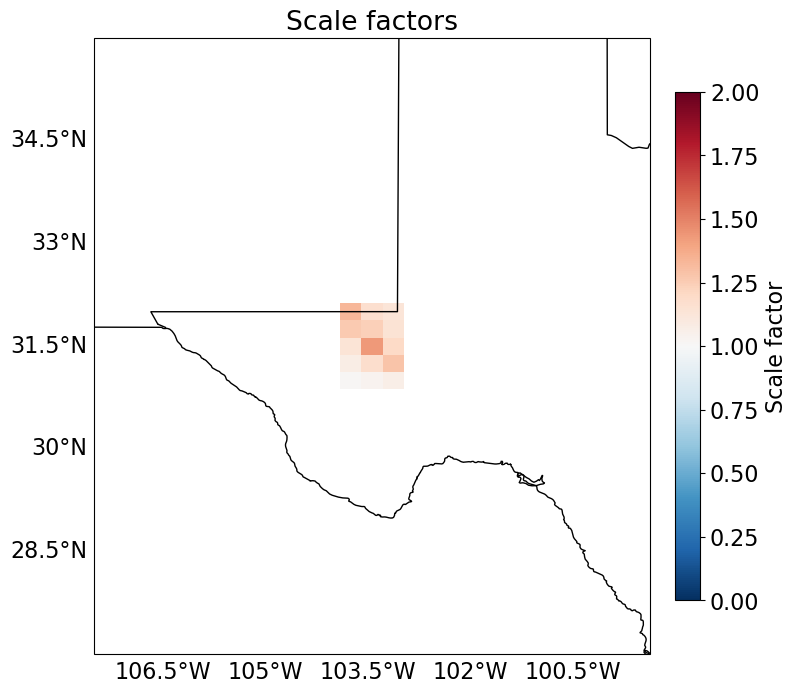

In [18]:
fig = plt.figure(figsize=(8, 8))
plt.rcParams.update({"font.size": 16})
ax = fig.subplots(1, 1, subplot_kw={"projection": ccrs.PlateCarree()})

if config['UseGCHP']:
    plot_field_gchp(
        ax,
        grid_ds['corner_lons'],
        grid_ds['corner_lats'],
        scale,
        cmap="RdBu_r",
        lon_bounds=lon_bounds,
        lat_bounds=lat_bounds,
        vmin=0,
        vmax=2,
        title="Scale factors",
        cbar_label="Scale factor",
        only_ROI=True,
        state_vector_labels=state_vector_labels,
        last_ROI_element=last_ROI_element,
        is_regional=config["isRegional"],
        stretch_grid=config['STRETCH_GRID'],
        save_path=plot_save_path
    )
else:
    plot_field(
        ax,
        scale,
        cmap="RdBu_r",
        lon_bounds=lon_bounds,
        lat_bounds=lat_bounds,
        vmin=0,
        vmax=2,
        title="Scale factors",
        cbar_label="Scale factor",
        only_ROI=True,
        state_vector_labels=state_vector_labels,
        last_ROI_element=last_ROI_element,
        is_regional=config["isRegional"],
        save_path=plot_save_path
    )

## Averaging kernel sensitivities

In [19]:
S_post_grid = xr.open_dataset(results_pth)["S_post"]
A_grid = xr.open_dataset(results_pth)["A"]
avkern_ROI = A_grid.where(state_vector_labels <= last_ROI_element)

Plot saved to ./output/averaging_kernel_sensitivities.png


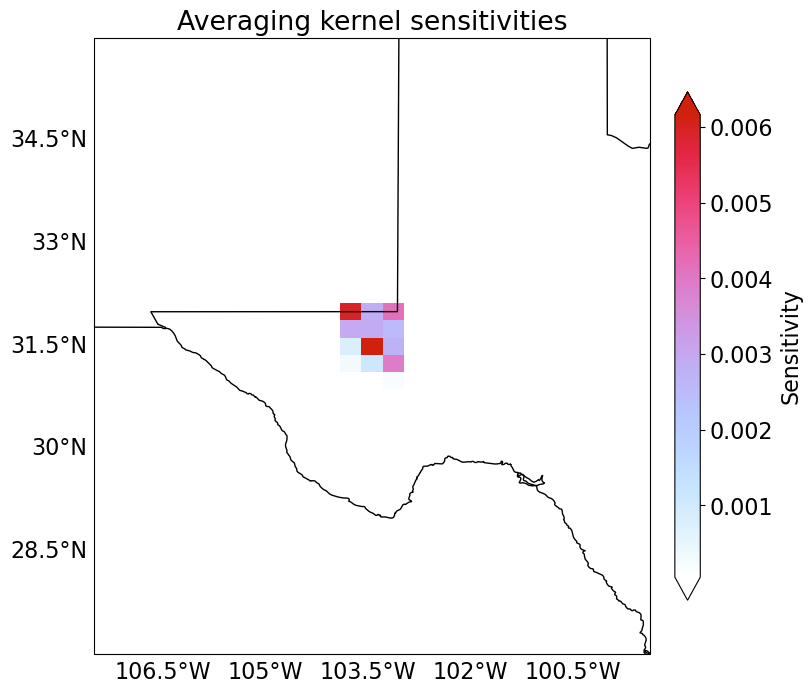

In [20]:
fig = plt.figure(figsize=(8, 8))
plt.rcParams.update({"font.size": 16})
ax = fig.subplots(1, 1, subplot_kw={"projection": ccrs.PlateCarree()})
vmin = np.nanpercentile(avkern_ROI, 5)
vmax = np.nanpercentile(avkern_ROI, 95)

if config['UseGCHP']:
    plot_field_gchp(
        ax,
        grid_ds['corner_lons'],
        grid_ds['corner_lats'],
        avkern_ROI,
        cmap=cc.cm.CET_L19,
        vmin=vmin,
        vmax=vmax,
        lon_bounds=lon_bounds,
        lat_bounds=lat_bounds,
        title="Averaging kernel sensitivities",
        cbar_label="Sensitivity",
        only_ROI=True,
        state_vector_labels=state_vector_labels,
        last_ROI_element=last_ROI_element,
        is_regional=config["isRegional"],
        stretch_grid=config['STRETCH_GRID'],
        save_path=plot_save_path
    )
else:
    plot_field(
        ax,
        avkern_ROI,
        cmap=cc.cm.CET_L19,
        vmin=vmin,
        vmax=vmax,
        lon_bounds=lon_bounds,
        lat_bounds=lat_bounds,
        title="Averaging kernel sensitivities",
        cbar_label="Sensitivity",
        only_ROI=True,
        state_vector_labels=state_vector_labels,
        last_ROI_element=last_ROI_element,
        is_regional=config["isRegional"],
        save_path=plot_save_path
    )

In [21]:
# ungridded inversion result is used to calculate DOFS using the trace of the averaging kernel
A_ROI = xr.open_dataset(inversion_result_path)["A"].values[:last_ROI_element, :last_ROI_element]
DOFS = np.trace(A_ROI)
print("DOFS =", DOFS)

DOFS = 0.0371116608914539


## Open satellite and GEOS-Chem columns

In [22]:
# Get observed and GEOS-Chem-simulated satellite columns
def aggregate_data(data_files, data_posterior_files, get_GCindex=False):
    lat = np.array([])
    lon = np.array([])
    satellite = np.array([])
    geos_prior = np.array([])
    geos_posterior = np.array([])
    observation_count = np.array([])
    if get_GCindex:
        GC_index = np.array([], dtype=int)
    for i in range(len(data_files)):
        # Get paths
        pth = data_files[i]
        pth_posterior = data_posterior_files[i]
        # Load satellite/GEOS-Chem and Jacobian matrix data from the .pkl file
        obj = load_obj(pth)
        # If there is no corresponding file in data_posterior dir, skip
        if not os.path.isfile(pth_posterior):
            continue
        obj_posterior = load_obj(pth_posterior)
        # If there aren't any satellite observations on this day, skip
        if obj["obs_GC"].shape[0] == 0:
            continue
        # Otherwise, grab the satellite/GEOS-Chem data
        obs_GC = obj["obs_GC"]
        obs_GC_posterior = obj_posterior["obs_GC"]
        # Only consider data within latitude and longitude bounds
        ind = np.where(
            (obs_GC[:, 2] >= lon_bounds[0])
            & (obs_GC[:, 2] <= lon_bounds[1])
            & (obs_GC[:, 3] >= lat_bounds[0])
            & (obs_GC[:, 3] <= lat_bounds[1])
        )
        if len(ind[0]) == 0:  # Skip if no data in bounds
            continue
        obs_GC = obs_GC[ind[0], :]  # satellite and GEOS-Chem data within bounds
        obs_GC_posterior = obs_GC_posterior[ind[0], :]
        # Record lat, lon, satellite mixing ratio, and geos mixing ratio
        lat = np.concatenate((lat, obs_GC[:, 3]))
        lon = np.concatenate((lon, obs_GC[:, 2]))
        satellite = np.concatenate((satellite, obs_GC[:, 0]))
        geos_prior = np.concatenate((geos_prior, obs_GC[:, 1]))
        observation_count = np.concatenate((observation_count, obs_GC[:, 4]))
        geos_posterior = np.concatenate((geos_posterior, obs_GC_posterior[:, 1]))

        if get_GCindex:
            GC_index = np.concatenate((GC_index, obj['GC_index'][ind[0]]))
    df = pd.DataFrame()
    df["lat"] = lat
    df["lon"] = lon
    df["satellite"] = satellite
    df["geos_prior"] = geos_prior
    df["geos_posterior"] = geos_posterior
    df["diff_satellite_prior"] = geos_prior - satellite
    df["diff_satellite_posterior"] = geos_posterior - satellite
    df["observation_count"] = observation_count
    if get_GCindex:
        df['GC_index'] = GC_index
    # Sort by latitude and longitude from northwest
    df = df.sort_values(by=["lat", "lon"], ascending=[False, True]).reset_index(drop=True)
    
    return df

def grid_superobs(config, superobs_df, gc_fpath, state_vector_filepath):
    varlist = ['satellite', 'geos_prior', 'geos_posterior', 'observation_count']
    long_name = ['Satellite observed methane concentrations',
                 'Methane concentrations from a prior simulation', 
                 'Methane concentrations from a posterior simulation',
                 'Number of observations in each simulation grid box']
    units = ['ppb', 'ppb', 'ppb', '1']
    
    def weighted_avg_column(df, val_col):
        return lambda x: np.average(df.loc[x.index, val_col], weights=df.loc[x.index, 'observation_count'])

    grouped = (
        superobs_df
        .groupby('GC_index', as_index=False)
        .agg({
            'observation_count': 'sum',
            'satellite': weighted_avg_column(superobs_df, 'satellite'),
            'geos_prior': weighted_avg_column(superobs_df, 'geos_prior'),
            'geos_posterior': weighted_avg_column(superobs_df, 'geos_posterior'),
        })
    )

    grouped['GC_index'] = grouped['GC_index'].astype(int)

    n_obs = len(grouped)

    # Read grid file
    GCds = xr.open_dataset(gc_fpath).squeeze()
    if config['UseGCHP']:
        lats = GCds['lats'].values
        lons = GCds['lons'].values
        GC_shape = lats.shape
    else:
        lat = GCds['lat'].values
        lon = GCds['lon'].values
        GC_shape = (len(lat), len(lon))

    var_values = np.full((len(varlist), *GC_shape), np.nan)

    for k in range(n_obs):
        gc_idx = grouped.loc[k, 'GC_index']
        if config['UseGCHP']:
            f, j, i = np.unravel_index(gc_idx, GC_shape)
            for vari in range(len(varlist)):
                var_values[vari, f, j, i] = grouped.loc[k, varlist[vari]]
        else:
            j, i = np.unravel_index(gc_idx, GC_shape)
            for vari in range(len(varlist)):
                var_values[vari, j, i] = grouped.loc[k, varlist[vari]]

    superobs_ds = xr.Dataset()

    if config['UseGCHP']:
        for vari in range(len(varlist)):
            superobs_ds[varlist[vari]] = xr.DataArray(
                var_values[vari, ...], dims=['nf', 'Ydim', 'Xdim'],
                coords=dict(lats=(['nf', 'Ydim', 'Xdim'], lats),
                            lons=(['nf', 'Ydim', 'Xdim'], lons)),
                attrs=dict(units=units[vari], long_name=long_name[vari])
            )

        superobs_ds['corner_lons'] = GCds['corner_lons']
        superobs_ds['corner_lats'] = GCds['corner_lats']
        superobs_ds.lats.attrs.update(units="degrees_north", long_name="Latitude")
        superobs_ds.lons.attrs.update(units="degrees_east", long_name="Longitude")

    else:
        for vari in range(len(varlist)):
            superobs_ds[varlist[vari]] = xr.DataArray(
                var_values[vari, ...], dims=['lat', 'lon'], coords=[lat, lon],
                attrs=dict(units=units[vari], long_name=long_name[vari])
            )

        superobs_ds.lat.attrs.update(units="degrees_north", long_name="Latitude")
        superobs_ds.lon.attrs.update(units="degrees_east", long_name="Longitude")

        # Subset to match statevector domain
        statevector_ds = xr.open_dataset(state_vector_filepath).squeeze()
        lon_range = [np.nanmin(statevector_ds['lon']), np.nanmax(statevector_ds['lon'])]
        lat_range = [np.nanmin(statevector_ds['lat']), np.nanmax(statevector_ds['lat'])]
        superobs_ds = superobs_ds.sel(
            lon=slice(lon_range[0], lon_range[1]),
            lat=slice(lat_range[0], lat_range[1])
        )

    superobs_ds['diff_satellite_prior'] = superobs_ds['geos_prior'] - superobs_ds['satellite']
    superobs_ds['diff_satellite_posterior'] = superobs_ds['geos_posterior'] - superobs_ds['satellite']
    # Add global attributes
    superobs_ds.attrs = {
        'Start date': config['StartDate'],
        'End date': config['EndDate']
    }

    return superobs_ds

gc_startdate = np.datetime64(datetime.datetime.strptime(str(config['StartDate']), "%Y%m%d"))
gc_enddate = np.datetime64(datetime.datetime.strptime(str(config['EndDate']), "%Y%m%d"))
allfiles = glob.glob(f"{satdat_dir}/*.pkl")
satdat_files = []
for index in range(len(allfiles)):
    filename = allfiles[index]
    shortname = re.split(r"\/", filename)[-1]
    shortname = re.split(r"\.", shortname)[0]
    strdate = re.split(r"\.|_+|T", shortname)[4]
    strdate = datetime.datetime.strptime(strdate, "%Y%m%d")
    if (strdate >= gc_startdate) and (strdate < gc_enddate):
        satdat_files.append(filename)
satdat_files.sort()

allfiles = glob.glob(f"{posterior_dir}/*.pkl")
posterior_files = []
for index in range(len(allfiles)):
    filename = allfiles[index]
    shortname = re.split(r"\/", filename)[-1]
    shortname = re.split(r"\.", shortname)[0]
    strdate = re.split(r"\.|_+|T", shortname)[4]
    strdate = datetime.datetime.strptime(strdate, "%Y%m%d")
    if (strdate >= gc_startdate) and (strdate < gc_enddate):
        posterior_files.append(filename)
posterior_files.sort()

allfiles = glob.glob(f"{visualization_dir}/*.pkl")
visualization_files = []
for index in range(len(allfiles)):
    filename = allfiles[index]
    shortname = re.split(r"\/", filename)[-1]
    shortname = re.split(r"\.", shortname)[0]
    strdate = re.split(r"\.|_+|T", shortname)[4]
    strdate = datetime.datetime.strptime(strdate, "%Y%m%d")
    if (strdate >= gc_startdate) and (strdate < gc_enddate):
        visualization_files.append(filename)
visualization_files.sort()

allfiles = glob.glob(f"{posterior_viz_dir}/*.pkl")
posterior_viz_files = []
for index in range(len(allfiles)):
    filename = allfiles[index]
    shortname = re.split(r"\/", filename)[-1]
    shortname = re.split(r"\.", shortname)[0]
    strdate = re.split(r"\.|_+|T", shortname)[4]
    strdate = datetime.datetime.strptime(strdate, "%Y%m%d")
    if (strdate >= gc_startdate) and (strdate < gc_enddate):
        posterior_viz_files.append(filename)
posterior_viz_files.sort()

superobs_df = aggregate_data(satdat_files, posterior_files, get_GCindex=True)
superobs_ds = grid_superobs(config, superobs_df, gc_fpath, state_vector_filepath)
netcdf_path = f"{plot_save_path}/netCDF"
os.makedirs(netcdf_path, exist_ok=True)  # Create the directory if it doesn't exist
superobs_fpathout = './output/netCDF/super_observations_GC.nc'
superobs_ds.to_netcdf(superobs_fpathout, mode='w')

visualization_df = aggregate_data(visualization_files, posterior_viz_files)

n_obs = len(superobs_df["satellite"])

print(
    f'Found {n_obs} super-observations in the domain, representing {np.sum(superobs_df["observation_count"]).round(0)} satellite observations.'
)
superobs_df.head(20)

Found 1229 super-observations in the domain, representing 9466.0 satellite observations.


,lat,lon,satellite,geos_prior,geos_posterior,diff_satellite_prior,diff_satellite_posterior,observation_count,GC_index
0,35.999889,-103.124985,1809.714111,1821.006836,1821.128540,11.292725,11.414429,15.190297,1418
1,35.999729,-100.312279,1826.058228,1830.977905,1829.178589,4.919678,3.120361,13.407548,1427
2,35.999527,-100.626060,1822.101685,1831.206909,1830.163696,9.105225,8.062012,13.707887,1426
3,35.998890,-104.648903,1803.610352,1813.761475,1814.433105,10.151123,10.822754,8.280022,1413
4,35.998798,-99.686951,1829.206421,1830.118408,1828.047119,0.911987,-1.159302,12.609282,1429
5,35.997257,-101.560478,1821.119629,1827.091309,1826.410400,5.971680,5.290771,14.267138,1423
6,35.994499,-102.818649,1812.419922,1823.138550,1823.253174,10.718628,10.833252,14.413005,1419
7,35.994110,-103.753181,1809.613892,1817.753784,1817.861572,8.139893,8.247681,11.287845,1416
8,35.993862,-101.539467,1833.665649,1828.082886,1829.987183,-5.582764,-3.678467,7.769905,1423
9,35.991753,-103.424927,1806.971558,1818.641357,1818.786865,11.669800,11.815308,10.113335,1417


Note: This observation count is for the lat/lon bounds defined in input cell 5.

In [23]:
# calculate some statistics for the prior
prior_std = np.round(np.std(superobs_df["diff_satellite_prior"]), 2)
prior_bias = np.round(
    np.average(
        superobs_df["diff_satellite_prior"], weights=superobs_df["observation_count"]
    ),
    2,
)
prior_RMSE = np.round(
    np.sqrt(
        np.average(
            superobs_df["diff_satellite_prior"] ** 2,
            weights=superobs_df["observation_count"],
        )
    ),
    2,
)

# and the posterior
posterior_std = np.round(np.std(superobs_df["diff_satellite_posterior"]), 2)
posterior_bias = np.round(
    np.average(
        superobs_df["diff_satellite_posterior"], weights=superobs_df["observation_count"]
    ),
    2,
)
posterior_RMSE = np.round(
    np.sqrt(
        np.average(
            superobs_df["diff_satellite_posterior"] ** 2,
            weights=superobs_df["observation_count"],
        )
    ),
    2,
)

# Print some error statistics
print(f"Bias in prior     : {prior_bias} +/- {prior_std} ppb")
print(f"RMSE prior        : {prior_RMSE} ppb")
print(f"Bias in posterior : {posterior_bias} +/- {posterior_std} ppb")
print(f"RMSE posterior    : {posterior_RMSE} ppb")

Bias in prior     : -4.53 +/- 9.26 ppb
RMSE prior        : 10.19 ppb
Bias in posterior : 0.45 +/- 8.17 ppb
RMSE posterior    : 7.95 ppb


## Count observations within the region of interest

In [24]:
print("Found", count_obs_in_mask(mask, superobs_df, config['UseGCHP']), "super-observations within the region of interest")

Found 30 super-observations within the region of interest


In [25]:
# simple function to find the dynamic range for colorbar
dynamic_range = lambda vals: (
    np.round(np.nanmedian(vals) / 25.0) * 25 - 25,
    np.round(np.nanmedian(vals) / 25.0) * 25 + 25,
)

## Compare satellite and GEOS-Chem columns

### Comparison at simulation resolution

Plot saved to ./output/satellite_xch4_on_gc_grid.png


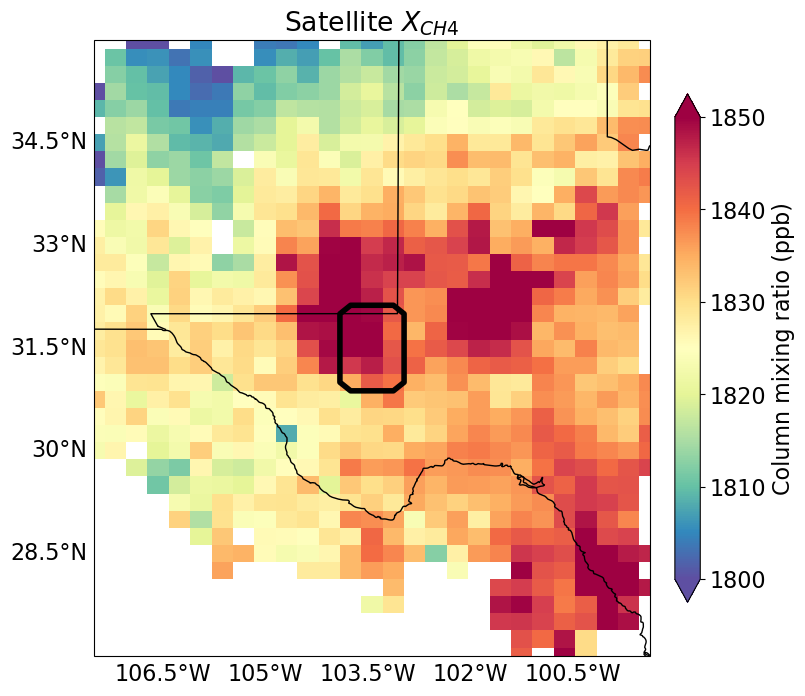

In [26]:
# Plot XCH4 from Satellite superobservations and GC 
ds = superobs_ds.copy()
# Mean satellite XCH4 columns on simulation grid
fig = plt.figure(figsize=(8, 8))
ax = fig.subplots(1, 1, subplot_kw={"projection": ccrs.PlateCarree()})

xch4_min, xch4_max = dynamic_range(ds["satellite"].values)

if config['UseGCHP']:
    plot_field_gchp(
        ax,
        grid_ds['corner_lons'],
        grid_ds['corner_lats'],
        ds["satellite"],
        cmap="Spectral_r",
        vmin=xch4_min,
        vmax=xch4_max,
        lon_bounds=lon_bounds,
        lat_bounds=lat_bounds,
        title="Satellite $X_{CH4}$",
        clean_title="Satellite XCH4 on GC grid",
        cbar_label="Column mixing ratio (ppb)",
        only_ROI=False,
        is_regional=config["isRegional"],
        stretch_grid=config['STRETCH_GRID'],
        save_path=plot_save_path
    )
else:
    plot_field(
        ax,
        ds["satellite"],
        cmap="Spectral_r",
        vmin=xch4_min,
        vmax=xch4_max,
        lon_bounds=lon_bounds,
        lat_bounds=lat_bounds,
        title="Satellite $X_{CH4}$",
        clean_title="Satellite XCH4 on GC grid",
        cbar_label="Column mixing ratio (ppb)",
        mask=mask,
        UseGCHP=config['UseGCHP'],
        only_ROI=False,
        is_regional=config["isRegional"],
        save_path=plot_save_path
    )

Plot saved to ./output/geos-chem_xch4_prior_and_posterior_on_gc_grid.png


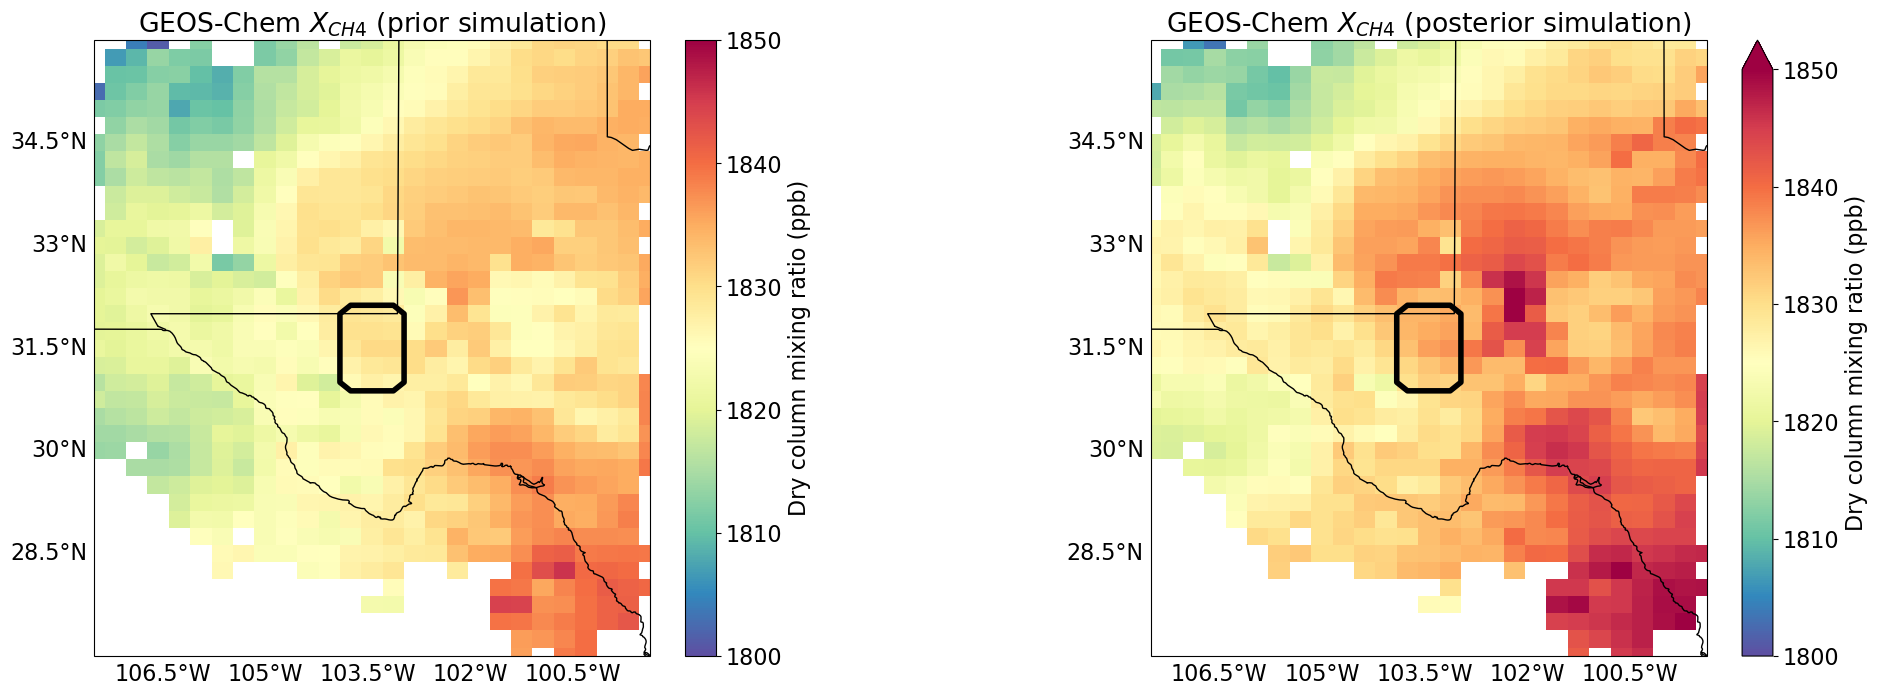

In [27]:
# Mean prior and posterior GEOS-Chem XCH4 columns on GC grid
fig = plt.figure(figsize=(25, 8))
ax1, ax2 = fig.subplots(1, 2, subplot_kw={"projection": ccrs.PlateCarree()})

if config['UseGCHP']:
    plot_field_gchp(
        ax1,
        grid_ds['corner_lons'],
        grid_ds['corner_lats'],
        ds["geos_prior"],
        cmap="Spectral_r",
        vmin=xch4_min,
        vmax=xch4_max,
        lon_bounds=lon_bounds,
        lat_bounds=lat_bounds,
        title="GEOS-Chem $X_{CH4}$ (prior simulation)",
        clean_title="GEOS-Chem XCH4 (prior) on GC grid",
        cbar_label="Dry column mixing ratio (ppb)",
        only_ROI=False,
        is_regional=config["isRegional"],
        stretch_grid=config['STRETCH_GRID'],
    )

    plot_field_gchp(
        ax2,
        grid_ds['corner_lons'],
        grid_ds['corner_lats'],
        ds["geos_posterior"],
        cmap="Spectral_r",
        vmin=xch4_min,
        vmax=xch4_max,
        lon_bounds=lon_bounds,
        lat_bounds=lat_bounds,
        title="GEOS-Chem $X_{CH4}$ (posterior simulation)",
        clean_title="GEOS-Chem XCH4 Prior_and_Posterior on GC grid",
        cbar_label="Dry column mixing ratio (ppb)",
        only_ROI=False,
        is_regional=config["isRegional"],
        stretch_grid=config['STRETCH_GRID'],
        save_path=plot_save_path
    )
else:
    plot_field(
        ax1,
        ds["geos_prior"],
        cmap="Spectral_r",
        vmin=xch4_min,
        vmax=xch4_max,
        lon_bounds=lon_bounds,
        lat_bounds=lat_bounds,
        title="GEOS-Chem $X_{CH4}$ (prior simulation)",
        clean_title="GEOS-Chem XCH4 (prior) on GC grid",
        cbar_label="Dry column mixing ratio (ppb)",
        mask=mask,
        UseGCHP=config['UseGCHP'],
        only_ROI=False,
        is_regional=config["isRegional"],
    )

    plot_field(
        ax2,
        ds["geos_posterior"],
        cmap="Spectral_r",
        vmin=xch4_min,
        vmax=xch4_max,
        lon_bounds=lon_bounds,
        lat_bounds=lat_bounds,
        title="GEOS-Chem $X_{CH4}$ (posterior simulation)",
        clean_title="GEOS-Chem XCH4 Prior_and_Posterior on GC grid",
        cbar_label="Dry column mixing ratio (ppb)",
        mask=mask,
        UseGCHP=config['UseGCHP'],
        only_ROI=False,
        is_regional=config["isRegional"],
        save_path=plot_save_path
    )

Plot saved to ./output/prior_and_posterior_-_satellite_on_gc_grid.png


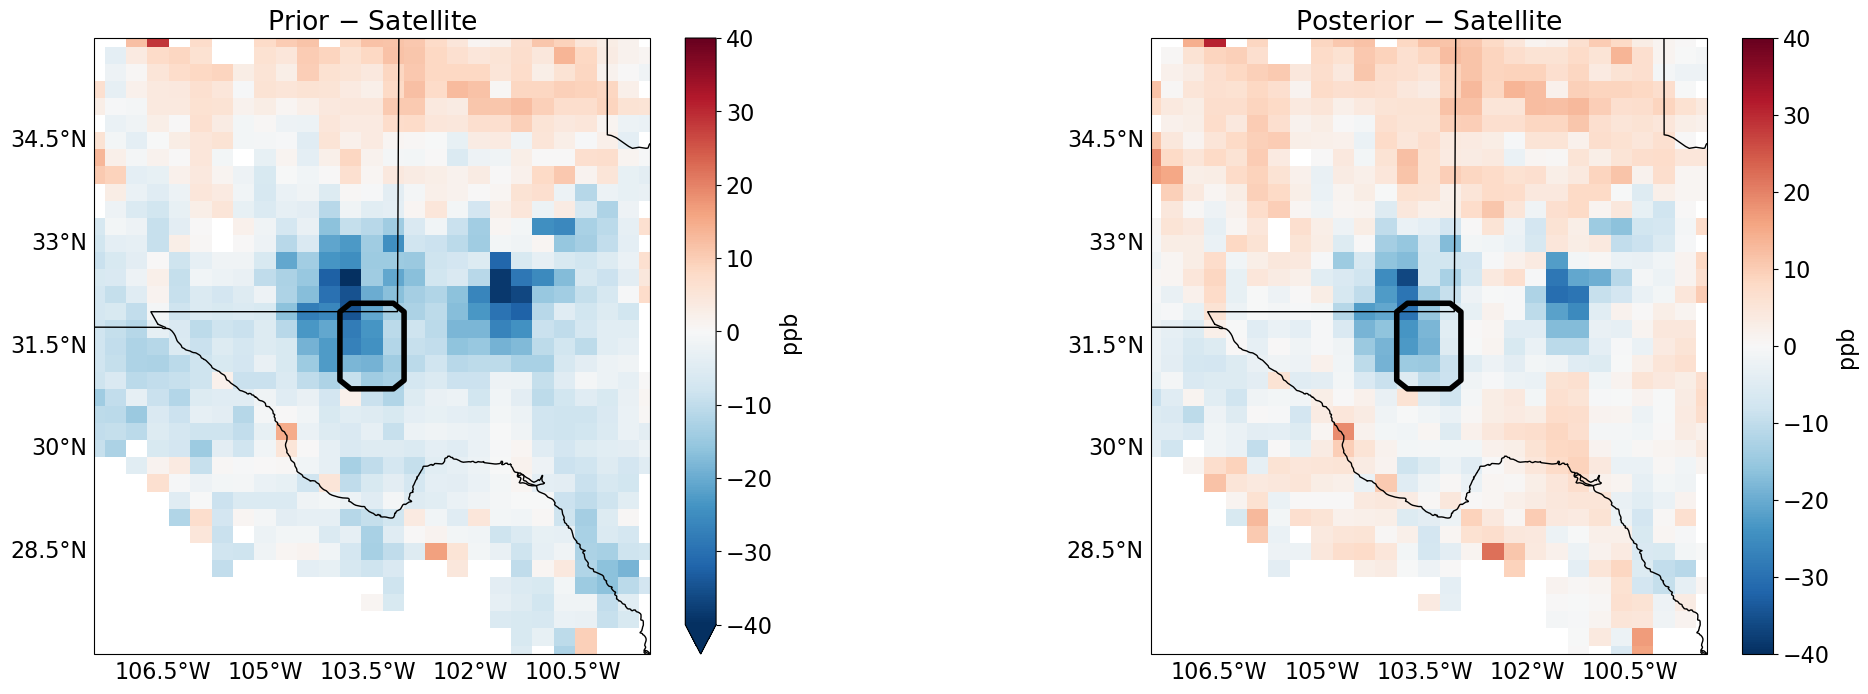

In [28]:
# Plot differences between GEOS-Chem and TROPOMI XCH4 on GC grid
fig = plt.figure(figsize=(25, 8))
ax1, ax2 = fig.subplots(1, 2, subplot_kw={"projection": ccrs.PlateCarree()})

if config['UseGCHP']:
    plot_field_gchp(
        ax1,
        grid_ds['corner_lons'],
        grid_ds['corner_lats'],
        ds["diff_satellite_prior"],
        cmap="RdBu_r",
        vmin=-40,
        vmax=40,
        lon_bounds=lon_bounds,
        lat_bounds=lat_bounds,
        title="Prior $-$ Satellite",
        clean_title="Prior-Satellite on GC grid",
        cbar_label="ppb",
        only_ROI=False,
        is_regional=config["isRegional"],
        stretch_grid=config['STRETCH_GRID'],
    )

    plot_field_gchp(
        ax2,
        grid_ds['corner_lons'],
        grid_ds['corner_lats'],
        ds["diff_satellite_posterior"],
        cmap="RdBu_r",
        vmin=-40,
        vmax=40,
        lon_bounds=lon_bounds,
        lat_bounds=lat_bounds,
        title="Posterior $-$ Satellite",
        clean_title="Prior_and_Posterior - Satellite on GC grid",
        cbar_label="ppb",
        only_ROI=False,
        is_regional=config["isRegional"],
        stretch_grid=config['STRETCH_GRID'],
        save_path=plot_save_path
    )
else:
    plot_field(
        ax1,
        ds["diff_satellite_prior"],
        cmap="RdBu_r",
        vmin=-40,
        vmax=40,
        lon_bounds=lon_bounds,
        lat_bounds=lat_bounds,
        title="Prior $-$ Satellite",
        clean_title="Prior-Satellite on GC grid",
        cbar_label="ppb",
        mask=mask,
        UseGCHP=config['UseGCHP'],
        only_ROI=False,
        is_regional=config["isRegional"],
    )

    plot_field(
        ax2,
        ds["diff_satellite_posterior"],
        cmap="RdBu_r",
        vmin=-40,
        vmax=40,
        lon_bounds=lon_bounds,
        lat_bounds=lat_bounds,
        title="Posterior $-$ Satellite",
        clean_title="Prior_and_Posterior - Satellite on GC grid",
        cbar_label="ppb",
        mask=mask,
        UseGCHP=config['UseGCHP'],
        only_ROI=False,
        is_regional=config["isRegional"],
        save_path=plot_save_path
    )

Plot saved to ./output/delta_xch4_posterior-prior_on_gc_grid.png


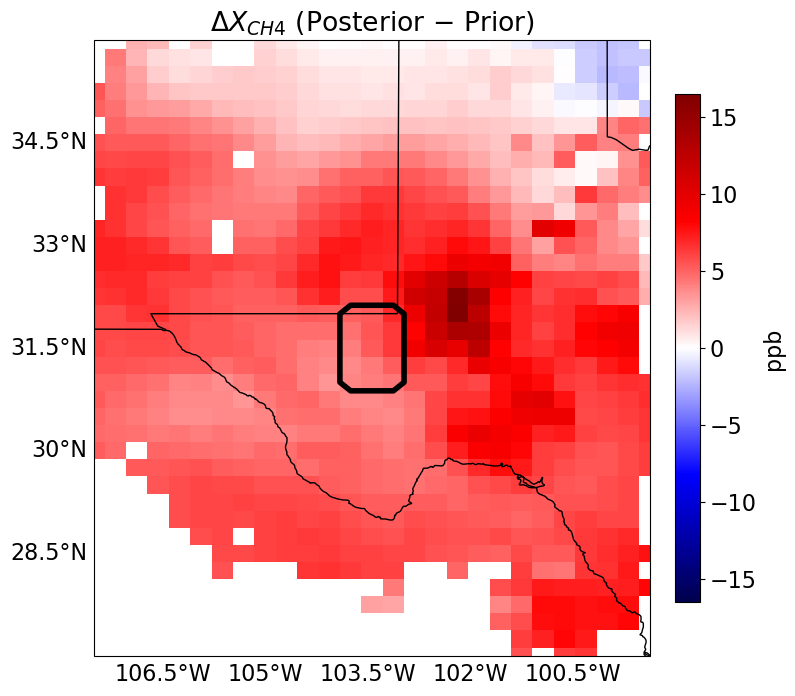

In [29]:
# Plot differences between posterior and prior simulated XCH4 on GC grid
fig = plt.figure(figsize=(8, 8))
ax = fig.subplots(1, 1, subplot_kw={"projection": ccrs.PlateCarree()})

ds['geos_diff'] = ds["geos_posterior"] - ds["geos_prior"]

if config['UseGCHP']:
    plot_field_gchp(
        ax,
        grid_ds['corner_lons'],
        grid_ds['corner_lats'],
        ds['geos_diff'],
        cmap="seismic",
        vmin=-np.nanmax(ds['geos_diff']),
        vmax=np.nanmax(ds['geos_diff']),
        lon_bounds=lon_bounds,
        lat_bounds=lat_bounds,
        title="$\Delta X_{CH4}$ (Posterior $-$ Prior)",
        clean_title="Delta XCH4 Posterior-Prior on GC grid",
        cbar_label="ppb",
        only_ROI=False,
        is_regional=config["isRegional"],
        stretch_grid=config['STRETCH_GRID'],
        save_path=plot_save_path
    )
else:
    plot_field(
        ax,
        ds['geos_diff'],
        cmap="seismic",
        vmin=-np.nanmax(ds['geos_diff']),
        vmax=np.nanmax(ds['geos_diff']),
        lon_bounds=lon_bounds,
        lat_bounds=lat_bounds,
        title="$\Delta X_{CH4}$ (Posterior $-$ Prior)",
        clean_title="Delta XCH4 Posterior-Prior on GC grid",
        cbar_label="ppb",
        mask=mask,
        UseGCHP=config['UseGCHP'],
        only_ROI=False,
        is_regional=config["isRegional"],
        save_path=plot_save_path
    )

### Comparison at 0.1 x 0.1 resolution

In [30]:
# Simple averaging scheme to grid the mixing ratio data at 0.1 x 0.1 resolution
df_copy = visualization_df.copy()  # save for later
visualization_df["lat"] = np.round(visualization_df["lat"], 1)
visualization_df["lon"] = np.round(visualization_df["lon"], 1)
visualization_df = visualization_df.groupby(["lat", "lon"]).mean()
ds = visualization_df.to_xarray()

Plot saved to ./output/satellite_xch4.png


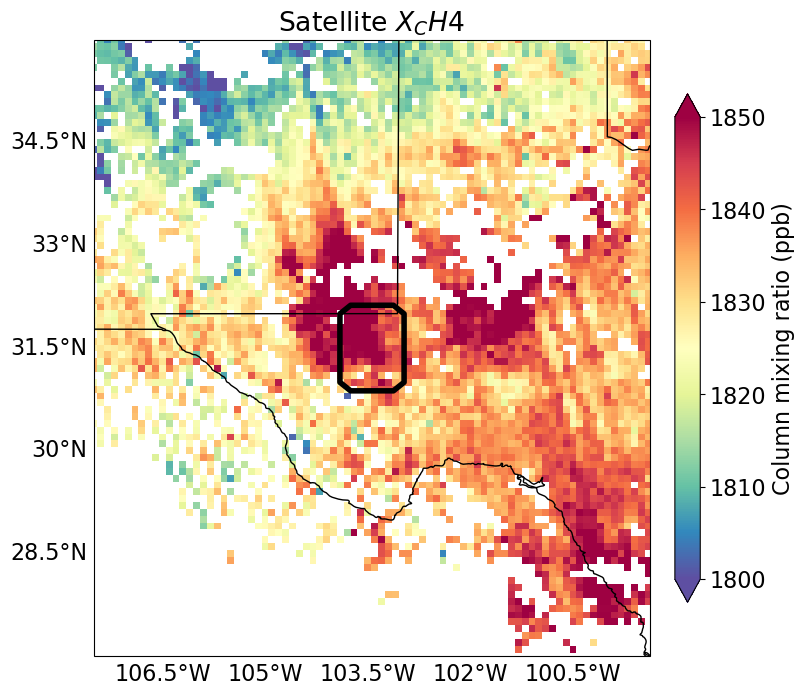

In [31]:
# Mean satellite mixing ratio columns on 0.1 x 0.1 grid
fig = plt.figure(figsize=(8, 8))
ax = fig.subplots(1, 1, subplot_kw={"projection": ccrs.PlateCarree()})

xch4_min, xch4_max = dynamic_range(ds["satellite"].values)
plot_field(
    ax,
    ds["satellite"],
    cmap="Spectral_r",
    vmin=xch4_min,
    vmax=xch4_max,
    lon_bounds=lon_bounds,
    lat_bounds=lat_bounds,
    title=f"Satellite $X_{species}$",
    clean_title=f"Satellite X{species}",
    cbar_label="Column mixing ratio (ppb)",
    mask=mask,
    UseGCHP=config['UseGCHP'],
    only_ROI=False,
    is_regional=config["isRegional"],
    save_path=plot_save_path
)

Plot saved to ./output/geos-chem_xch4_(prior&posterior).png


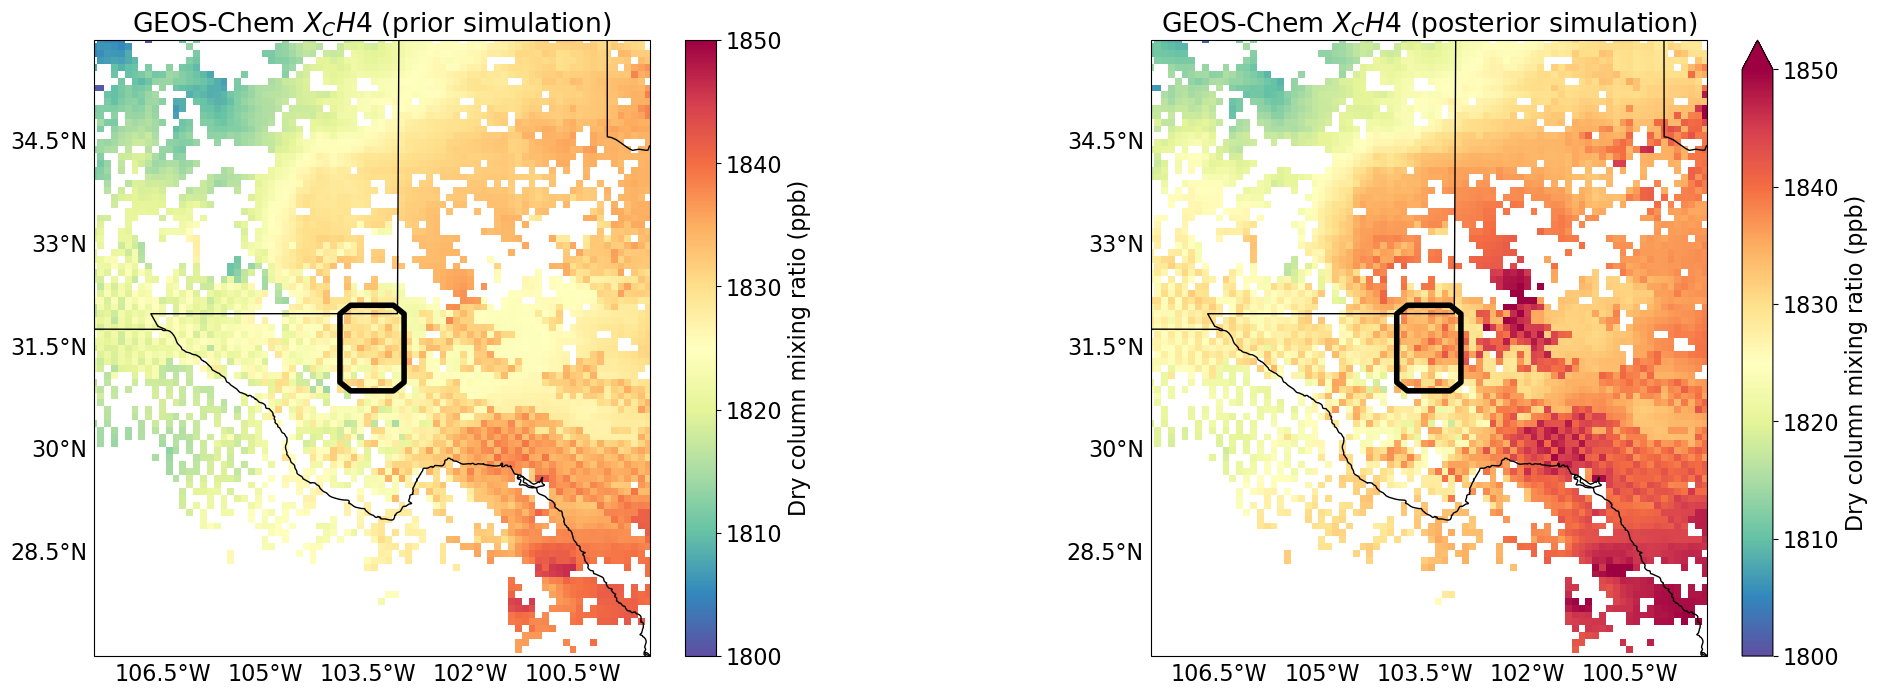

In [32]:
# Mean prior and posterior GEOS-Chem mixing ratio columns on 0.1 x 0.1 grid
fig = plt.figure(figsize=(25, 8))
ax1, ax2 = fig.subplots(1, 2, subplot_kw={"projection": ccrs.PlateCarree()})

plot_field(
    ax1,
    ds["geos_prior"],
    cmap="Spectral_r",
    vmin=xch4_min,
    vmax=xch4_max,
    lon_bounds=lon_bounds,
    lat_bounds=lat_bounds,
    title=f"GEOS-Chem $X_{species}$ (prior simulation)",
    clean_title=f"GEOS-Chem X{species} (prior)",
    cbar_label="Dry column mixing ratio (ppb)",
    mask=mask,
    UseGCHP=config['UseGCHP'],
    only_ROI=False,
    is_regional=config["isRegional"],
)

plot_field(
    ax2,
    ds["geos_posterior"],
    cmap="Spectral_r",
    vmin=xch4_min,
    vmax=xch4_max,
    lon_bounds=lon_bounds,
    lat_bounds=lat_bounds,
    title=f"GEOS-Chem $X_{species}$ (posterior simulation)",
    clean_title=f"GEOS-Chem X{species} (Prior&Posterior)",
    cbar_label="Dry column mixing ratio (ppb)",
    mask=mask,
    UseGCHP=config['UseGCHP'],
    only_ROI=False,
    is_regional=config["isRegional"],
    save_path=plot_save_path
)

Plot saved to ./output/(prior&posterior)-satellite.png


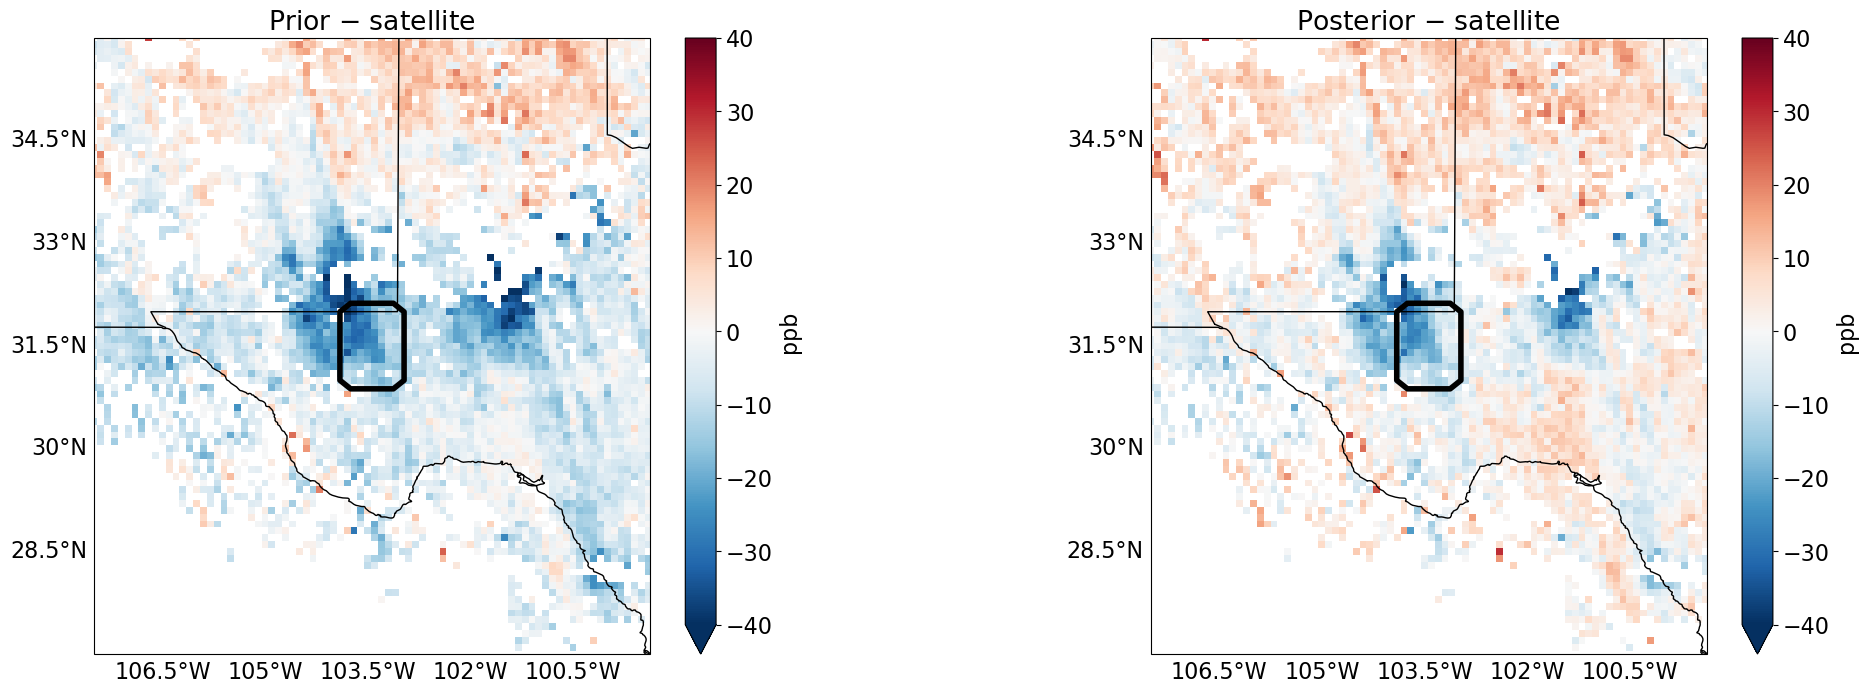

In [33]:
# Plot differences between GEOS-Chem and satellite mixing ratios
fig = plt.figure(figsize=(25, 8))
ax1, ax2 = fig.subplots(1, 2, subplot_kw={"projection": ccrs.PlateCarree()})

plot_field(
    ax1,
    ds["diff_satellite_prior"],
    cmap="RdBu_r",
    vmin=-40,
    vmax=40,
    lon_bounds=lon_bounds,
    lat_bounds=lat_bounds,
    title="Prior $-$ satellite",
    clean_title="Prior-satellite",
    cbar_label="ppb",
    mask=mask,
    UseGCHP=config['UseGCHP'],
    only_ROI=False,
    is_regional=config["isRegional"],
)

plot_field(
    ax2,
    ds["diff_satellite_posterior"],
    cmap="RdBu_r",
    vmin=-40,
    vmax=40,
    lon_bounds=lon_bounds,
    lat_bounds=lat_bounds,
    title="Posterior $-$ satellite",
    clean_title="(Prior&Posterior)-satellite",
    cbar_label="ppb",
    mask=mask,
    UseGCHP=config['UseGCHP'],
    only_ROI=False,
    is_regional=config["isRegional"],
    save_path=plot_save_path
)

Plot saved to ./output/delta_xch4_(posterior-prior).png


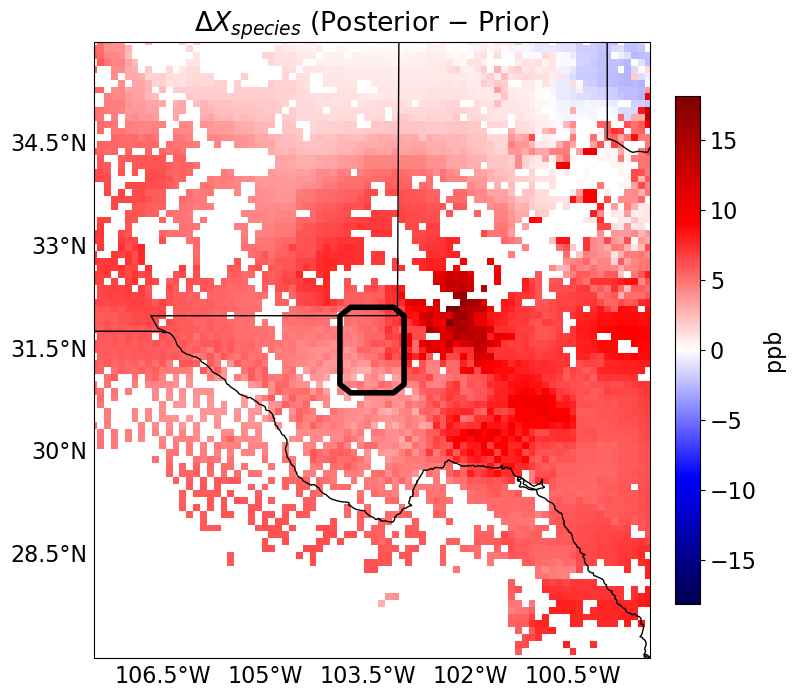

In [34]:
# Plot differences between posterior and prior simulated mixing ratios
fig = plt.figure(figsize=(8, 8))
ax = fig.subplots(1, 1, subplot_kw={"projection": ccrs.PlateCarree()})

ds['geos_diff'] = ds["geos_posterior"] - ds["geos_prior"]

plot_field(
    ax,
    ds['geos_diff'],
    cmap="seismic",
    vmin=-np.nanmax(ds['geos_diff']),
    vmax=np.nanmax(ds['geos_diff']),
    lon_bounds=lon_bounds,
    lat_bounds=lat_bounds,
    title=f"$\Delta X_{{species}}$ (Posterior $-$ Prior)",
    clean_title=f"Delta X{species} (Posterior-Prior)",
    cbar_label="ppb",
    mask=mask,
    UseGCHP=config['UseGCHP'],
    only_ROI=False,
    is_regional=config["isRegional"],
    save_path=plot_save_path
)

### Comparison at 0.25 x 0.3125 resolution

In [35]:
# Simple averaging scheme to grid the mixing ratio data at 0.1 x 0.1 resolution
df_copy = superobs_df.copy()  # save for later
superobs_df["lat"] = np.round(superobs_df["lat"], 1)
superobs_df["lon"] = np.round(superobs_df["lon"], 1)
superobs_df = superobs_df.groupby(["lat", "lon"]).mean()
superobs_df = superobs_df.reset_index()

In [36]:
# Fill in any missing lat/lon coordinates at .1 degree spacing
new_lat_values = np.arange(ds["lat"][0], ds["lat"][-1] + 0.1, 0.1)
new_lon_values = np.arange(ds["lon"][0], ds["lon"][-1] + 0.1, 0.1)

data = []
# Iterate through latitude and longitude combinations
for lat in new_lat_values:
    for lon in new_lon_values:
        data.append({"lat": lat, "lon": lon, "value": None})

# Create a new DataFrame from the data
df_temp = pd.DataFrame(data)

# ensure matching sigfigs with superobs_df
df_temp["lat"] = np.round(df_temp["lat"], 1)
df_temp["lon"] = np.round(df_temp["lon"], 1)

# merge the two dataframes and drop the filler column
# then convert to xarray dataset
merged_df = pd.merge(df_temp, superobs_df, on=["lat", "lon"], how="left").drop(
    columns=["value"]
)
ds = xr.Dataset.from_dataframe(merged_df.set_index(["lat", "lon"]))

In [37]:
# calculate the grid bounds for .1x.1 grid
lat_b = np.arange(ds["lat"][0] - 0.05, ds["lat"][-1] + 0.1, 0.1)
lon_b = np.arange(ds["lon"][0] - 0.05, ds["lon"][-1] + 0.1, 0.1)
ds = ds.assign_coords(lon_b=("lon_b", lon_b))
ds = ds.assign_coords(lat_b=("lat_b", lat_b))
ds["mask"] = xr.where(~np.isnan(ds["satellite"]), 1, 0)

In [38]:
# Global 0.25 x 0.3125 grid
reference_lat_grid = np.arange(-90, 90 + 0.25, 0.25)
reference_lon_grid = np.arange(-180, 180 + 0.3125, 0.3125)

# Find closest reference coordinates to selected lat/lon bounds
lat_min = reference_lat_grid[np.abs(reference_lat_grid - lat_bounds[0]).argmin()]
lon_min = reference_lon_grid[np.abs(reference_lon_grid - lon_bounds[0]).argmin()]
lat_max = reference_lat_grid[np.abs(reference_lat_grid - lat_bounds[1]).argmin()]
lon_max = reference_lon_grid[np.abs(reference_lon_grid - lon_bounds[1]).argmin()]

# Create an xESMF regridder object to resample the data on the grid HEMCO expects
new_lat_grid = np.arange(lat_min, lat_max + 0.25, 0.25)
new_lon_grid = np.arange(lon_min, lon_max + 0.3125, 0.3125)
new_lat_b = np.arange(new_lat_grid[0] - 0.125, new_lat_grid[-1] + 0.25, 0.25)
new_lon_b = np.arange(new_lon_grid[0] - 0.15625, new_lon_grid[-1] + 0.3125, 0.3125)

# remove edge due to the use of global lat and lon bounds in GCHP
if config['UseGCHP']:
    new_lat_grid = new_lat_grid[1:-1]
    new_lon_grid = new_lon_grid[1:-1]
    new_lat_b = new_lat_b[1:-1]
    new_lon_b = new_lon_b[1:-1]
ds_out = xr.Dataset(
    {
        "lat": (["lat"], new_lat_grid),
        "lon": (["lon"], new_lon_grid),
        "lat_b": (["lat_b"], new_lat_b),
        "lon_b": (["lon_b"], new_lon_b),
    }
)

regridder = xe.Regridder(ds, ds_out, "conservative_normed")

# Regrid the data
ds_regrid = regridder(ds)

Plot saved to ./output/(prior&posterior)-satellite_(regridded).png


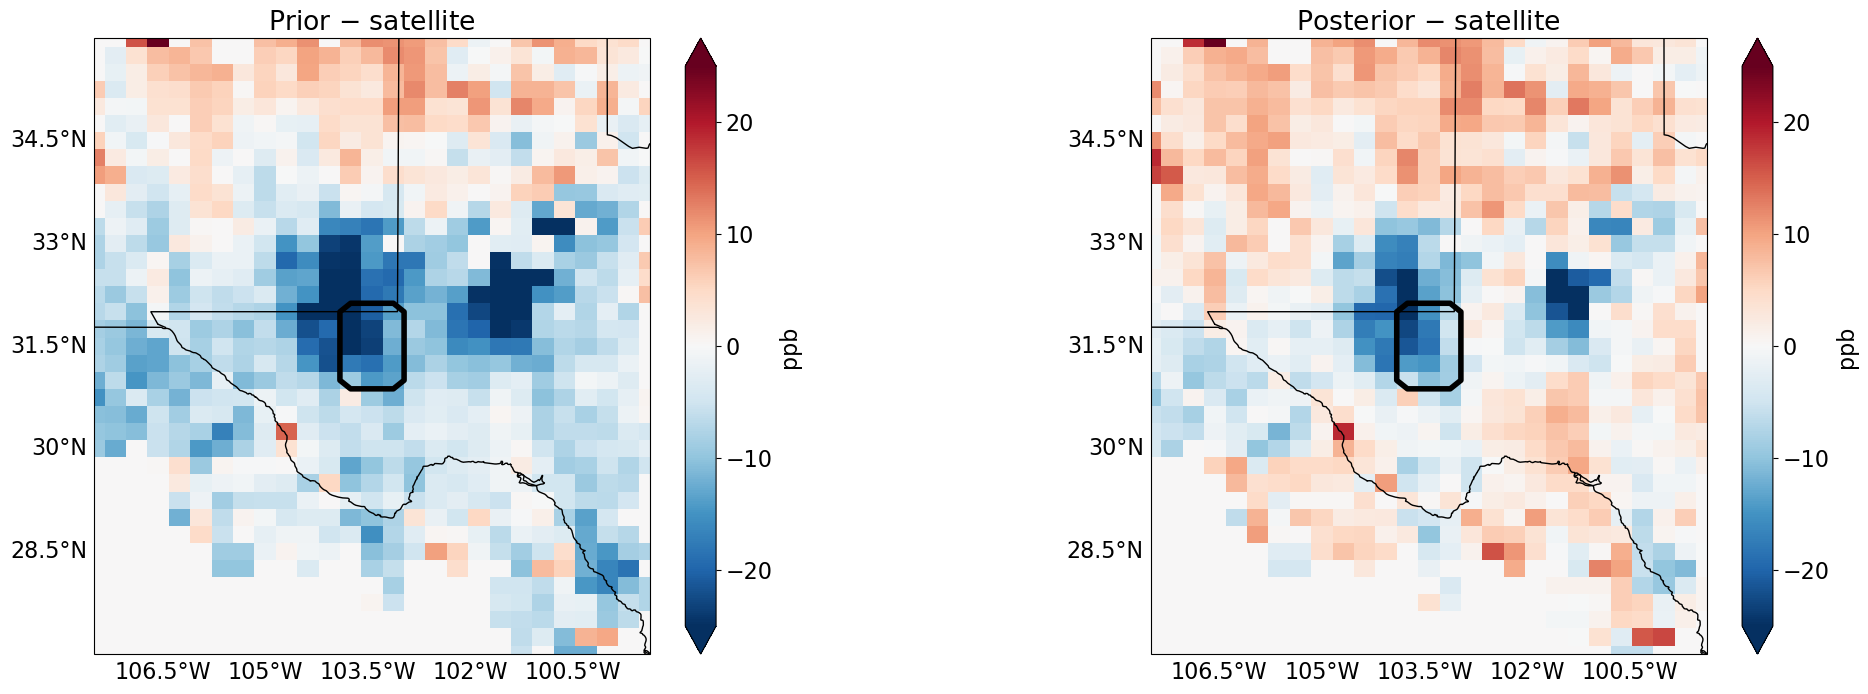

In [39]:
# Re-plot differences between GEOS-Chem and satellite mixing ratios
fig = plt.figure(figsize=(25, 8))
ax1, ax2 = fig.subplots(1, 2, subplot_kw={"projection": ccrs.PlateCarree()})

plot_field(
    ax1,
    ds_regrid["diff_satellite_prior"],
    cmap="RdBu_r",
    vmin=-25,
    vmax=25,
    lon_bounds=lon_bounds,
    lat_bounds=lat_bounds,
    title="Prior $-$ satellite",
    clean_title="Prior-satellite (regridded)",
    cbar_label="ppb",
    mask=mask,
    UseGCHP=config['UseGCHP'],
    only_ROI=False,
    is_regional=config["isRegional"],
)

plot_field(
    ax2,
    ds_regrid["diff_satellite_posterior"],
    cmap="RdBu_r",
    vmin=-25,
    vmax=25,
    lon_bounds=lon_bounds,
    lat_bounds=lat_bounds,
    title="Posterior $-$ satellite",
    clean_title="(Prior&Posterior)-satellite (regridded)",
    cbar_label="ppb",
    mask=mask,
    UseGCHP=config['UseGCHP'],
    only_ROI=False,
    is_regional=config["isRegional"],
    save_path=plot_save_path
)

Plot saved to ./output/posterior-prior_(regridded).png


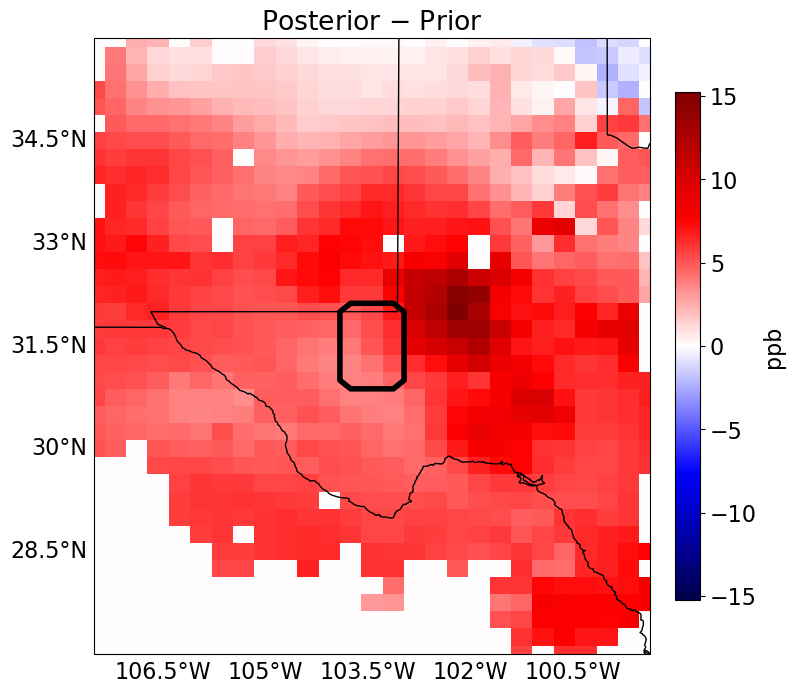

In [40]:
# Re-plot differences between posterior and prior simulated mixing ratios
fig = plt.figure(figsize=(8, 8))
ax = fig.subplots(1, 1, subplot_kw={"projection": ccrs.PlateCarree()})

ds_regrid['geos_diff'] = ds_regrid["geos_posterior"] - ds_regrid["geos_prior"]

plot_field(
    ax,
    ds_regrid["geos_diff"],
    cmap="seismic",
    vmin=-np.nanmax(ds_regrid["geos_diff"]),
    vmax=np.nanmax(ds_regrid["geos_diff"]),
    lon_bounds=lon_bounds,
    lat_bounds=lat_bounds,
    title="Posterior $-$ Prior",
    clean_title="Posterior-Prior (regridded)",
    cbar_label="ppb",
    mask=mask,
    UseGCHP=config['UseGCHP'],
    only_ROI=False,
    is_regional=config["isRegional"],
    save_path=plot_save_path
)

In [41]:
# Export visualization outputs
_ = export_visualization_outputs(
    plot_save_path=plot_save_path,
    start_date=start_date,
    end_date=end_date,
    total_prior_emissions=total_prior_emissions,
    total_posterior_emissions=total_posterior_emissions,
    DOFS=DOFS,
    prior_bias=prior_bias,
    posterior_bias=posterior_bias,
    prior_std=prior_std,
    posterior_std=posterior_std,
    prior_RMSE=prior_RMSE,
    posterior_RMSE=posterior_RMSE,
    df_for_count=df_copy,
    mask=mask,
    combined_sorted=combined_sorted,
    prior_ds=prior_ds,
    posterior_ds=posterior_ds,
    areas=areas,
    num_ensemble_members=num_ensemble_members,
    ens_totals_posterior=(ens_totals_posterior if num_ensemble_members > 1 else None),
    ens_inv_result=(ens_inv_result if num_ensemble_members > 1 else None),
    ens_scale_ds=(ens_scale_ds if num_ensemble_members > 1 else None),
    state_vector_labels=state_vector_labels,
    scale=scale,
    avkern_ROI=avkern_ROI,
    ds_obs=ds,
    ds_obs_regridded=ds_regrid,
)


----